# Grondwaterstand SWF
Met dit notebook kan de gemiddelde grondwaterstand bepaald worden per buurt, en per welstandsgebied. Deze wordt dan ook vergeleken met de voorspelling grondwaterstand 2050 hoog. De datafiles zij van toepassing op de gemeente sudwest fryslan.

#### Setup
samen met dit notebook zouden de volgende bestanden verschaft moeten zijn:
```
gemeentegrens_2018.gpkg
cbs_buurten.gpkg
welstandsgebieden.gpkg
SWF_Gemiddelde Laagste Grondwaterstand 2050 Hoog.tif
SWF_Gemiddelde Laagste Grondwaterstand Huidig.tif
SWF-GWS.yml
```
De eerste 5 zijn datasets die gebruikt worden in de analyze. De laaste is de .yml file die door conda gebruikt kan worden voor het installeren van een environment met alle packages nodig om dit script te runnen. gebruik de console command ```conda env create -f SWF-GWS.yml``` daarvoor. Dit gaat er natuurlijk van uit dat je zelf al anaconda of miniconda op je pc hebt geinstalleerd.

In [1]:
import xarray as xr
import rioxarray
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import pyogrio
from pathlib import Path
import os
import time
import datetime
import numpy as np

### Filepaths
Voor het vormen en bewerken van filepaths wordt de pathlib library gebruikt, dit is een opvolger voor de os.path module. Pathlib biedt meer uniform support tussen de filesystems van verschillende operating systems. Huidige code gaat uit van de current working directory, indien de data in een andere folders staat gebruik dan: ```folderpath = Path(r'schijf_letter:\parent_folder\...\end_folder')``` voor windows

In [2]:
# vind alle geotiffs en geopackages
folderpath = Path.cwd() #haalt de huidige folder op waarin jupyter aan het werk is.
GWS_huidig_filepath = folderpath / "SWF_Gemiddelde Laagste Grondwaterstand Huidig.tif"
GWS_2050_filepath = folderpath / "SWF_Gemiddelde Laagste Grondwaterstand 2050 Hoog.tif"
gemeentegrens_filepath = folderpath / "gemeentegrens_2018.gpkg"
buurten_filepath = folderpath / "cbs_buurten.gpkg"
welstandsgebieden_L0_bodemsoorten_L1_filepath = folderpath / "welstandsgebieden_L0_Bodemsoorten_L1.gpkg"
print(GWS_huidig_filepath,"\n",GWS_2050_filepath,"\n",gemeentegrens_filepath,"\n",buurten_filepath,"\n", welstandsgebieden_L0_bodemsoorten_L1_filepath)

C:\Werk\SWF\Grondwaterstand\SWF_Gemiddelde Laagste Grondwaterstand Huidig.tif 
 C:\Werk\SWF\Grondwaterstand\SWF_Gemiddelde Laagste Grondwaterstand 2050 Hoog.tif 
 C:\Werk\SWF\Grondwaterstand\gemeentegrens_2018.gpkg 
 C:\Werk\SWF\Grondwaterstand\cbs_buurten.gpkg 
 C:\Werk\SWF\Grondwaterstand\welstandsgebieden_L0_Bodemsoorten_L1.gpkg


Controleer of alle benodigde bestanden aanwezig zijn.

### raster data: meetingen grondwaterstand
Voor het openen, bewerken en opslaan van raster data bestanden wordt de library xarray gebruikt. Deze library heeft verschillende backend dependancies zoals GDAL numpy en rioxarray.

In [3]:
# open grondwaterstand huidig en print wat details
GWS_ds = xr.open_dataset(GWS_huidig_filepath,decode_times=True)
GWS_ds = GWS_ds.squeeze("band", drop=True)
GWS_ds = GWS_ds.rename({"band_data":"GWS huidig"})
print(GWS_ds)
print(GWS_ds.rio.crs)
print(GWS_ds.rio.bounds())
print(GWS_ds.attrs)
print(GWS_ds.dtypes)

<xarray.Dataset> Size: 113kB
Dimensions:      (x: 170, y: 162)
Coordinates:
  * x            (x) float64 1kB 1.399e+05 1.401e+05 ... 1.819e+05 1.821e+05
  * y            (y) float64 1kB 5.744e+05 5.741e+05 ... 5.344e+05 5.341e+05
    spatial_ref  int64 8B ...
Data variables:
    GWS huidig   (y, x) float32 110kB ...
EPSG:28992
(139750.0, 534000.0, 182250.0, 574500.0)
{}
Frozen({'GWS huidig': dtype('float32')})


In [4]:
GWS_ds["GWS huidig"][80:90,90:100].data

array([[1.21765 , 1.20518 , 1.05645 , 0.947771, 1.19259 , 1.04157 ,
             nan,      nan, 0.849277,      nan],
       [1.28916 , 1.25187 , 1.13114 , 1.03922 , 0.900181, 0.929036,
        0.930482, 1.12096 , 1.06922 , 0.853614],
       [1.19687 , 1.19078 , 1.26331 , 1.05663 , 0.838554,      nan,
        0.881627, 1.09392 , 0.859036, 0.786928],
       [1.0794  , 1.16024 , 0.942229,      nan,      nan,      nan,
        0.871325, 0.83506 , 0.681265, 0.547711],
       [1.07006 , 1.04982 , 0.876687, 0.890301,      nan, 0.730723,
             nan,      nan,      nan,      nan],
       [1.04958 ,      nan,      nan,      nan,      nan, 0.773916,
             nan,      nan,      nan,      nan],
       [1.10337 , 0.789879,      nan, 0.986807, 0.993675,      nan,
             nan,      nan,      nan, 0.718675],
       [1.07934 ,      nan,      nan, 0.732168,      nan,      nan,
             nan,      nan, 0.768675, 0.794277],
       [1.20512 ,      nan, 0.862169, 0.832651, 0.76747 ,      n

Als er metadata in het bestand aanwezig is dan is die niet opgeslagen op de manier zoals xarray het had verwacht, gezien de attributen variable van het object leeg is zoals te zien is in de bovenstaande regel.

In [5]:
#open grondwaterstand hoog en print wat details
GWS_hoog = xr.open_dataset(GWS_2050_filepath)
GWS_hoog = GWS_hoog.squeeze("band", drop=True)
GWS_hoog = GWS_hoog.rename({"band_data":"GWS hoog"})
print(GWS_hoog)
print(GWS_hoog.rio.crs)
print(GWS_hoog.rio.bounds())
print(GWS_hoog.dtypes)

<xarray.Dataset> Size: 113kB
Dimensions:      (x: 170, y: 162)
Coordinates:
  * x            (x) float64 1kB 1.399e+05 1.401e+05 ... 1.819e+05 1.821e+05
  * y            (y) float64 1kB 5.744e+05 5.741e+05 ... 5.344e+05 5.341e+05
    spatial_ref  int64 8B ...
Data variables:
    GWS hoog     (y, x) float32 110kB ...
EPSG:28992
(139750.0, 534000.0, 182250.0, 574500.0)
Frozen({'GWS hoog': dtype('float32')})


In [6]:
#stop beide dataset in één xarray object en bekijk resultaat
GWS_ds = GWS_ds.merge(GWS_hoog)
print(GWS_ds)
print(GWS_ds.dtypes)

<xarray.Dataset> Size: 223kB
Dimensions:      (x: 170, y: 162)
Coordinates:
  * x            (x) float64 1kB 1.399e+05 1.401e+05 ... 1.819e+05 1.821e+05
  * y            (y) float64 1kB 5.744e+05 5.741e+05 ... 5.344e+05 5.341e+05
    spatial_ref  int64 8B 0
Data variables:
    GWS huidig   (y, x) float32 110kB ...
    GWS hoog     (y, x) float32 110kB ...
Frozen({'GWS huidig': dtype('float32'), 'GWS hoog': dtype('float32')})


C:\Users\siebr\AppData\Local\Temp\ipykernel_13728\3928890776.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  GWS_ds = GWS_ds.merge(GWS_hoog)


### Vectordata: gebied_SWF
Voor het openen, bewerken en opslaan van vectordata wordt de library geopandas gebruikt. Ook deze library heeft backend dependancies zoals pandas, numpy, pyogrio, fiona, GDAL en matplotlib.
Geopandas kan maar één dataframe per laag tegelijk maken. Voor geopackages met meerdere lagen zou je een dictionary kunnen maken waarbij je elke laag als aparte entry inleest.
```python
# lees alle lagen en sla elk op als een aparte entry in dictionary
gebied_layers = gpd.list_layers(vectorfiles[0])["name"]
gebied_dfs_dict = {}
for layer in gebied_layers:
    new_data = gpd.read_file(vectorfiles[0], layer = layer)
    gebied_dfs_dict[layer] = new_data

#selecteer en inspecteer één van de lagen
gebied_df_relevant = gebied_dfs_dict[gebied_layers[0]]
gebied_df_relevant.head()
```

In [7]:
#check hoeveel layers
gebied_layers = gpd.list_layers(gemeentegrens_filepath)
print(gebied_layers)

                 name       geometry_type
0  gemeentegresn_2018  GeometryCollection


<Axes: >

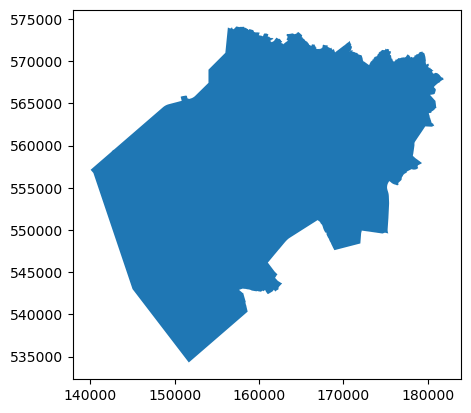

In [8]:
gebied_SWF = gpd.read_file(gemeentegrens_filepath)
gebied_SWF.plot()

In [9]:
#check crs
gebied_SWF.crs

<Projected CRS: EPSG:28992>
Name: Amersfoort / RD New
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Netherlands - onshore, including Waddenzee, Dutch Wadden Islands and 12-mile offshore coastal zone.
- bounds: (3.2, 50.75, 7.22, 53.7)
Coordinate Operation:
- name: RD New
- method: Oblique Stereographic
Datum: Amersfoort
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

### Waterstand meetingen volledige gemeente
Selecteer de rasterdata van de waterstand op het gebied van de volledige gemeente.

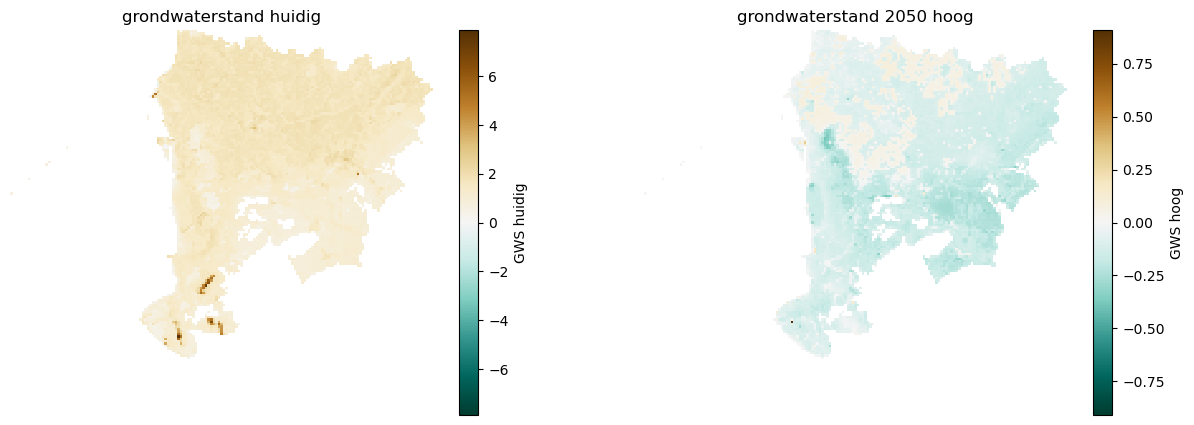

In [10]:
# als crs van raster data en vector data overeen komen, selecteer dan alle rasterdata die binnen sudwest fryslan valt
assert gebied_SWF.crs == GWS_ds.rio.crs
GWS_SWF_ds = GWS_ds.rio.clip(geometries = gebied_SWF.geometry, crs = GWS_ds.rio.crs)

# plot vectordata van het resultaat
figure, axis = plt.subplots(1,2,figsize=(15,5))
axis[0].axis("off")
axis[1].axis("off")
GWS_SWF_ds["GWS huidig"].plot(ax = axis[0], cmap="BrBG_r")
GWS_SWF_ds["GWS hoog"].plot(ax = axis[1], cmap="BrBG_r")
axis[0].set_title("grondwaterstand huidig")
axis[1].set_title("grondwaterstand 2050 hoog");

### Functie gemiddelde waarde per gebied
met onderstaande functie kan de gemiddelde waarde per gebied worden berekend.

In [11]:
def gemiddelde_per_gebied(raster_data_ds,gebieden_df):
    """Bereken de gemiddelde waarde(s) per gebied.
    
    Neemt een xarray dataset met rasterdata van één of meerdere meeteenheden, 
    en een geopandas dataframe met vectordata van één of meerdere gebieden 
    (die binnen het gebied van de rasterdata vallen). 
    Vervolgens wordt de gemiddelde waarde per gebied berekend voor elke meeteenheid.

    parameters:
    raster_data_ds: xarray dataset
    gebieden_df: geopandas dataframe

    returns:
    een dataframe geleijk aan gebieden_df, met een extra kolom voor elke meeteenheid.

    resultaat_df: geopandas dataframe
    """
    assert raster_data_ds.rio.crs == gebieden_df.crs
    resultaat_df = gebieden_df.copy()
    data_labels = list(raster_data_ds.data_vars.keys())
    for label in data_labels:
        resultaat_df[label] = pd.Series()
    for index_pos, huidig_gebied in gebieden_df.iterrows():
        try:
            subset = raster_data_ds.rio.clip(geometries = [huidig_gebied['geometry']], crs = gebieden_df.crs, all_touched=True)
            for label in data_labels:
                gemiddelde = subset.mean(skipna = True)[label].item()
                if not pd.isna(gemiddelde):
                    resultaat_df.loc[index_pos, label] = gemiddelde
                else:
                    resultaat_df.drop(index = index_pos, inplace = True)
                    break
        except:
            resultaat_df.drop(index = index_pos, inplace = True)
    return resultaat_df

In plaats van gemiddelde waarde kunnen er ook makkelijk andere statistische functies worden gebruikt, zoals:
```python
subset.max()
subset.min()
subset.mean()
subset.median()
subset.prod()
subset.sum()
subset.std()
subset.var()
subset.cumsum()
subset.cumprod()
```

### Waterstand per buurt
Bepaal de gemiddelde waterstand per buurt.

In [12]:
#controleer hoeveelheid lagen in cbs_buurten
buurt_layers = gpd.list_layers(buurten_filepath)
buurt_layers

,name,geometry_type
0,cbs_buurten,MultiPolygon


Met maar één laag in het bestand is er geen verdere moeilijkheid voor het inlezen van de data

In [13]:
# lees cbs_buurten en verwijder uit de data de twee die niet relevant zijn
buurten_df = gpd.read_file(buurten_filepath)
drop_index = buurten_df.loc[buurten_df['BU_CODE'].isin(['BU19009997' , 'BU19009998'])].index # maaken een index die alle ongewenste rijen flagt als True
buurten_df = buurten_df.drop(drop_index) #drop verwijdert hele rijen incl. indexlabel, dit kan een sprong in de index achterlaten
buurten_df = buurten_df.reset_index(drop = True) #indien de index simpelweg een oplopende reeks is, dan kan je hiermee de sprongen weghalen, en dus de reeks herstellen
buurten_df.tail() # inspecteer de data

,BU_CODE,BU_NAAM,WK_CODE,IsWater,geometry
150,BU19002015,Britswert,WK190020,NEE,"MULTIPOLYGON (((174600.946 571352.588, 174600...."
151,BU19002016,Wiuwert,WK190020,NEE,"MULTIPOLYGON (((175680.799 570396.289, 175694...."
152,BU19002017,Boazum,WK190020,NEE,"MULTIPOLYGON (((175571.5 567420, 175785.5 5673..."
153,BU19002018,Easterwierrum,WK190020,NEE,"MULTIPOLYGON (((176602.072 570362.61, 176614.7..."
154,BU19002019,Verspreide huizen Boazum,WK190020,NEE,"MULTIPOLYGON (((178112.99 568547.375, 178111.0..."


Twee buurtcodes waren niet relevant voor de analyze en zijn verwijdert uit de dataset.

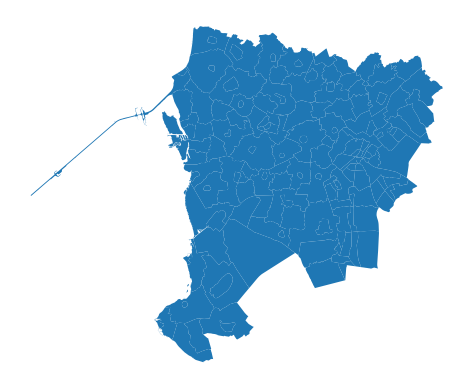

In [14]:
# plot map van alle buurten
ax = buurten_df.plot()
ax.axis("off");

In [15]:
# bereken gemiddelde grondwaterstand waardde per buurt
buurten_GWS_df = gemiddelde_per_gebied(GWS_SWF_ds,buurten_df)
print(buurten_GWS_df[['GWS huidig','GWS hoog']].head())#controleer resultaat

  GWS huidig  GWS hoog
0   1.996532 -0.058372
1   1.694068 -0.064949
2    1.73923 -0.064327
3   1.782562 -0.061403
4   1.714876 -0.080387


Voor elke buurt is de gemiddle grondwaterstand huidig, en hoog berekend, en opgeslagen in het dataframe object wat ook alle geometrie voor alle buurten bevat: ```buurten_df```.

In [16]:
# inspecteer datatypes
buurten_GWS_df.dtypes

BU_CODE         object
BU_NAAM         object
WK_CODE         object
IsWater         object
geometry      geometry
GWS huidig      object
GWS hoog        object
dtype: object

Voor de meeste kolommen is het datatype object, voor veel daarvan is een meer geschikt datatype aanwezig.

In [17]:
# inspecteer dataframe om te kijken welke datatypes gesicht zijn
buurten_GWS_df.head()

,BU_CODE,BU_NAAM,WK_CODE,IsWater,geometry,GWS huidig,GWS hoog
0,BU19000000,Bolsward binnen De Wallen,WK190000,NEE,"MULTIPOLYGON (((164284.479 564409.781, 164302....",1.996532,-0.058372
1,BU19000001,Bolsward-Noord,WK190000,NEE,"MULTIPOLYGON (((164107.667 565052.799, 164157....",1.694068,-0.064949
2,BU19000002,Bolsward-Zuidoost,WK190000,NEE,"MULTIPOLYGON (((164467 564371.688, 164531.797 ...",1.73923,-0.064327
3,BU19000003,Bolsward-Zuidwest,WK190000,NEE,"MULTIPOLYGON (((163646.554 563984.152, 163667....",1.782562,-0.061403
4,BU19000004,Bolsward-Noordoost,WK190000,NEE,"MULTIPOLYGON (((163997.873 565321.412, 164076....",1.714876,-0.080387


In [18]:
# met alleen maar land in het dataframe is de kolom 'IsWater' niet meer relevant. alternatief zou dit naar een boolean omgezet kunnen worden.
if "IsWater" in buurten_GWS_df.columns:
    buurten_GWS_df.drop(columns="IsWater",inplace=True)
# de rest van de datatypes wordt omgezet naar string of float32 afhankelijk van de opgegeven dictionary
buurten_GWS_df = buurten_GWS_df.astype({'BU_CODE':str,'BU_NAAM':str,'WK_CODE':str,'GWS huidig':float,'GWS hoog':float})

In [19]:
buurten_GWS_df.dtypes

BU_CODE         object
BU_NAAM         object
WK_CODE         object
geometry      geometry
GWS huidig     float64
GWS hoog       float64
dtype: object

Nu zijn de datatypes van het dataframe beter gepast.

### Waterstand per welvaardsgebied
Bepaal de gemiddelde waterstand per welvaardsgebied.

In [20]:
welstand_layers = gpd.list_layers(welstandsgebieden_L0_bodemsoorten_L1_filepath)
print(welstand_layers)

                name       geometry_type
0  welstandsgebieden  GeometryCollection
1       Bodemsoorten  GeometryCollection


In [21]:
welstandsgebieden_df = gpd.read_file(welstandsgebieden_L0_bodemsoorten_L1_filepath, layer = 0)
welstandsgebieden_df.rename(columns={"D_SWF_WELSTANDSGEBIEDEN_SK":"GEBIEDSCODE"},inplace=True)
welstandsgebieden_df.head()

,GEBIEDSCODE,GEBIED,AANDUIDING,DATE_FROM,DATE_TO,MODIFICATION,OPPERVLAKTE,geometry
0,21,Historische kernen,21 - Historische kernen,2020-01-01,NaT,NaT,60548.72,"MULTIPOLYGON (((169453 553523.3, 169453.002 55..."
1,22,Historische kernen,22 - Historische kernen,2020-01-01,NaT,NaT,50579.82,"MULTIPOLYGON (((157343.518 566401.257, 157343...."
2,23,Historische kernen,23 - Historische kernen,2020-01-01,NaT,NaT,49144.46,"MULTIPOLYGON (((168280.946 568965.584, 168280...."
3,24,Historische kernen,24 - Historische kernen,2020-01-01,NaT,NaT,48204.69,"MULTIPOLYGON (((171924.278 568220.381, 171924...."
4,25,Historische kernen,25 - Historische kernen,2020-01-01,NaT,NaT,43503.53,"MULTIPOLYGON (((165580.061 566671.06, 165580.0..."


<Axes: >

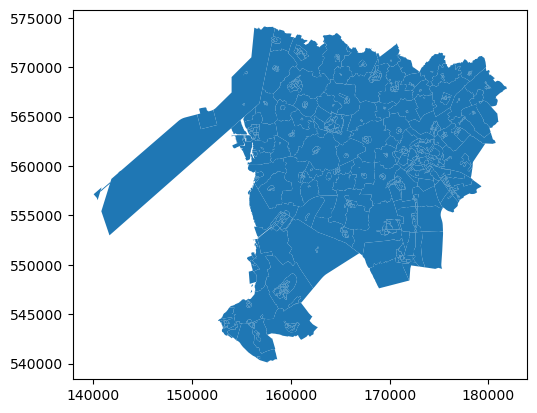

In [22]:
welstandsgebieden_df.plot()

In [23]:
# bereken de gemiddlede waardes, en controleer of ze toegevoegd zijn
welstandsgebieden_GWS = gemiddelde_per_gebied(GWS_SWF_ds,welstandsgebieden_df)
welstandsgebieden_GWS.head()

C:\Users\siebr\miniforge3\envs\Sieb-SWF-Conda\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape None at index 0 will not be rasterized.
  warnings.warn(


,GEBIEDSCODE,GEBIED,AANDUIDING,DATE_FROM,DATE_TO,MODIFICATION,OPPERVLAKTE,geometry,GWS huidig,GWS hoog
0,21,Historische kernen,21 - Historische kernen,2020-01-01,NaT,NaT,60548.72,"MULTIPOLYGON (((169453 553523.3, 169453.002 55...",1.35263,-0.133535
1,22,Historische kernen,22 - Historische kernen,2020-01-01,NaT,NaT,50579.82,"MULTIPOLYGON (((157343.518 566401.257, 157343....",1.728237,-0.002755
2,23,Historische kernen,23 - Historische kernen,2020-01-01,NaT,NaT,49144.46,"MULTIPOLYGON (((168280.946 568965.584, 168280....",1.822033,-0.0589
3,24,Historische kernen,24 - Historische kernen,2020-01-01,NaT,NaT,48204.69,"MULTIPOLYGON (((171924.278 568220.381, 171924....",1.761037,0.009412
4,25,Historische kernen,25 - Historische kernen,2020-01-01,NaT,NaT,43503.53,"MULTIPOLYGON (((165580.061 566671.06, 165580.0...",1.78848,-0.099622


<Axes: >

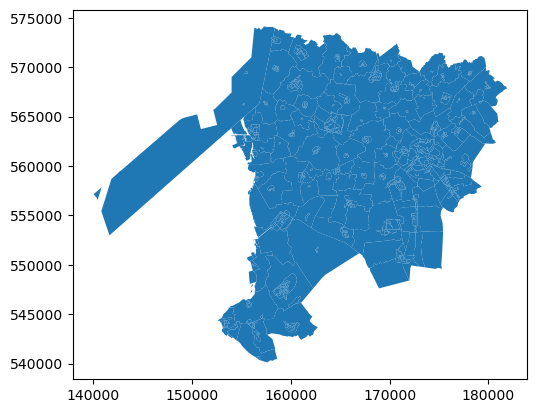

In [24]:
welstandsgebieden_GWS.plot()

In [25]:
#controleer datatypes
welstandsgebieden_GWS.dtypes

GEBIEDSCODE             object
GEBIED                  object
AANDUIDING              object
DATE_FROM       datetime64[ms]
DATE_TO         datetime64[ms]
MODIFICATION    datetime64[ms]
OPPERVLAKTE            float64
geometry              geometry
GWS huidig              object
GWS hoog                object
dtype: object

In [26]:
#pas datatypes aan, en bereken verschil in GWS huidig en GWS hoog
welstandsgebieden_GWS = welstandsgebieden_GWS.astype({"GEBIEDSCODE":int,"GEBIED":str,"AANDUIDING":str,"GWS huidig":float,"GWS hoog":float})
welstandsgebieden_GWS["GWS verschil"] = welstandsgebieden_GWS["GWS hoog"] - welstandsgebieden_GWS["GWS huidig"]
welstandsgebieden_GWS.head()

,GEBIEDSCODE,GEBIED,AANDUIDING,DATE_FROM,DATE_TO,MODIFICATION,OPPERVLAKTE,geometry,GWS huidig,GWS hoog,GWS verschil
0,21,Historische kernen,21 - Historische kernen,2020-01-01,NaT,NaT,60548.72,"MULTIPOLYGON (((169453 553523.3, 169453.002 55...",1.352630,-0.133535,-1.486165
1,22,Historische kernen,22 - Historische kernen,2020-01-01,NaT,NaT,50579.82,"MULTIPOLYGON (((157343.518 566401.257, 157343....",1.728237,-0.002755,-1.730992
2,23,Historische kernen,23 - Historische kernen,2020-01-01,NaT,NaT,49144.46,"MULTIPOLYGON (((168280.946 568965.584, 168280....",1.822033,-0.058900,-1.880933
3,24,Historische kernen,24 - Historische kernen,2020-01-01,NaT,NaT,48204.69,"MULTIPOLYGON (((171924.278 568220.381, 171924....",1.761037,0.009412,-1.751625
4,25,Historische kernen,25 - Historische kernen,2020-01-01,NaT,NaT,43503.53,"MULTIPOLYGON (((165580.061 566671.06, 165580.0...",1.788480,-0.099622,-1.888103


### Visualizatie grondwaterstand per buurt en welstandsgebied
Om de analyse te controleren maken we vescheidenen plots waar de grondwaterstand op weergegeven wordt.

Deze code is in V2 minder relevant: maak plot van grondwaterstand per buurt met 6 verschillende kleur waardes met bereik gegroepeerd volgens 'NaturalBreaks' schema. 
``` python
ax = buurten_GWS_df.plot(
    column = "GWS huidig",
    edgecolor = "black",
    linewidth = 0.1,
    legend = True,
    cmap = "BrBG_r",
    scheme = 'NaturalBreaks',
    k = 6,
    legend_kwds = {"fmt":"{:.01f}M",
                   "interval":"True",
                   "loc":"upper right", 
                   "bbox_to_anchor":(0.93,0.518,0.5,0.5)}
    );
ax.set_axis_off();
ax.set_title("grondwaterstand diepte per buurt (huidig)");
```
Het bereik van de grondwaterstand wordt opgedeelt in K=6 verschillende groepen, waarbij het bereik van elke groep individueel wordt bepaalt volgens het 'natural break' schema. De schemas worden berekend door de mapclassify library. Andere schema opties zijn: ‘box_plot’, ‘equal_interval’, ‘fisher_jenks’, ‘fisher_jenks_sampled’, ‘headtail_breaks’, ‘jenks_caspall’, ‘jenks_caspall_forced’, ‘jenks_caspall_sampled’, ‘max_p_classifier’, ‘maximum_breaks’, ‘natural_breaks’, ‘quantiles’, ‘percentiles’, ‘std_mean’ or ‘user_defined’.
Er wordt een warning over memory leaks gegeven, tot noch toe lijkt er geen probleem te zijn. Zou dit veranderen dan kan men in de toekomst kijken of het limiteren van cpu cores wat de python kernel mag gebruiken het oplost.

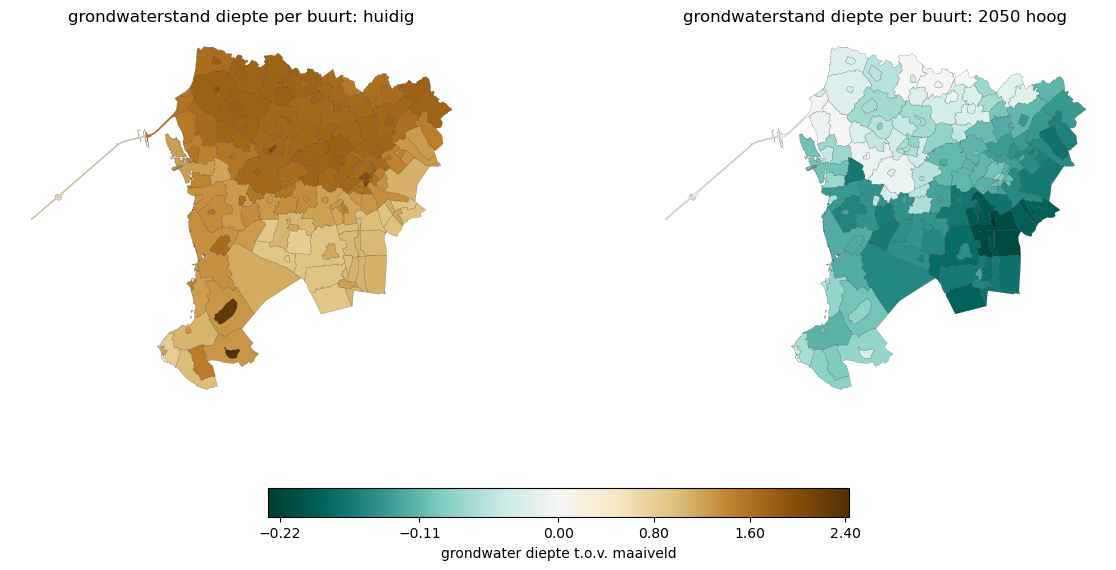

In [27]:
# maak plots met een continue kleurschaal. met bruin voor grondwater diepte boven 0 en blauw voor onder 0.
vmin = buurten_GWS_df["GWS hoog"].min()
vmax = buurten_GWS_df["GWS huidig"].max()
divnorm = mpl.colors.TwoSlopeNorm(vmin = vmin, vmax = vmax, vcenter = 0)
figure, axis = plt.subplots(1,2,figsize=(15,7))
buurten_GWS_df.plot(ax = axis[0],
                    column = "GWS huidig",
                    edgecolor = "black",
                    linewidth = 0.1,
                    #legend = True,
                    cmap = "BrBG_r",
                    norm = divnorm
                   )
buurten_GWS_df.plot(ax = axis[1],
                    column = "GWS hoog",
                    edgecolor = "black",
                    linewidth = 0.1,
                    legend = True,
                    cmap = "BrBG_r",
                    norm = divnorm,
                    legend_kwds = {"ax":axis,
                                   "label":"grondwater diepte t.o.v. maaiveld",
                                   "location":"bottom",
                                   "orientation":"horizontal",
                                   "shrink":0.5,
                                   "ticks":[-0.22,-0.11,0,0.8,1.6,2.4]})
axis[0].axis("off");
axis[1].axis("off");
axis[0].set_title("grondwaterstand diepte per buurt: huidig");
axis[1].set_title("grondwaterstand diepte per buurt: 2050 hoog");

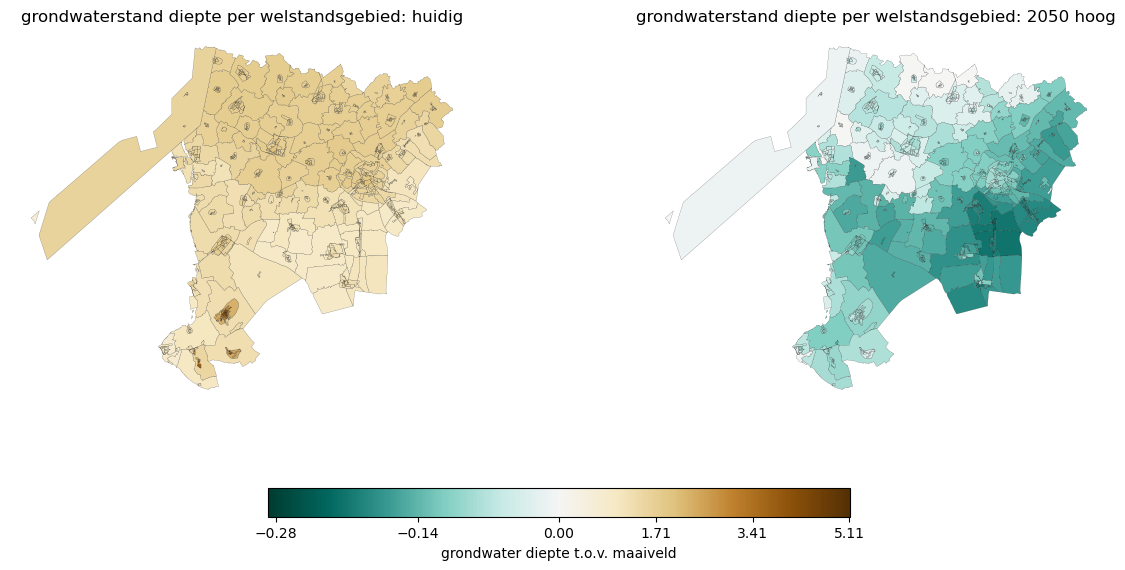

In [28]:
vmin = welstandsgebieden_GWS["GWS hoog"].min()
vmax = welstandsgebieden_GWS["GWS huidig"].max()
divnorm = mpl.colors.TwoSlopeNorm(vmin = vmin, vmax = vmax, vcenter = 0)
ticks = [round(vmin+0.01,2),round(vmin/2,2),0,round(vmax/3,2),round((vmax*2)/3,2),round(vmax-0.01,2)]
figure, axis = plt.subplots(1,2,figsize=(15,7))
welstandsgebieden_GWS.plot(ax = axis[0],
                           column = "GWS huidig",
                           edgecolor = "black",
                           linewidth = 0.1,
                           cmap = "BrBG_r",
                           norm = divnorm
                   )
welstandsgebieden_GWS.plot(ax = axis[1],
                           column = "GWS hoog",
                           edgecolor = "black",
                           linewidth = 0.1,
                           legend = True,
                           cmap = "BrBG_r",
                           norm = divnorm,
                           legend_kwds = {"ax":axis,
                                          "label":"grondwater diepte t.o.v. maaiveld",
                                          "location":"bottom",
                                          "orientation":"horizontal",
                                          "shrink":0.5,
                                          "ticks":ticks})
axis[0].axis("off");
axis[1].axis("off");
axis[0].set_title("grondwaterstand diepte per welstandsgebied: huidig");
axis[1].set_title("grondwaterstand diepte per welstandsgebied: 2050 hoog");

### opslaan van de nieuwe data
Het dataframe met de nieuwe data kan natuurlijk in hetzelfde format opgeslagen worden als hoe de oorspronkelijke data is aangeleverd (.gpkg), maar de data kan bijvoorbeeld ook naar een PostGIS database geupload worden met ```geopandas.GeoDataFrame.to_postgis()```.
Verdere supported file formats kunnen gevonden worden met ```pyogrio.list_drivers()```. Een output folder word aagemaakt om conflicten met het inlezen van aanwezige bestanden te voorkomen in de situatie dat dit script meermaals in eenzelfde folder wordt gebruikt.

```python
def get_times(filepath):
    stats = os.stat(filepath)
    creation_time = time.ctime(stats.st_ctime)
    last_modified_time = time.ctime(stats.st_mtime)
    last_accessed_time = time.ctime(stats.st_atime)
    print(f"creation:{creation_time}\n modified:{last_modified_time}\n accessed:{last_accessed_time}")
    return (creation_time, last_modified_time, last_accessed_time)
```

Bovenstaande functie kan gebruikt worden om tijden uit een specifiek bestand te halen. Hier is dat niet heel relevant.

wat code die gebruikt kan word voor het verwerken van timestamps in de data.
```python
# vul de lege tijden in en pas format aan voor output.
welstandsgebieden_GWS["DATE_TO"] = np.datetime64("2050-01-01")
welstandsgebieden_GWS["MODIFICATION"] = np.datetime64("today")
welstandsgebieden_GWS.rename(columns={"GWS hoog":"GWS 2050 hoog"}, inplace = True)
```

In [29]:
welstandsgebieden_GWS.tail()

,GEBIEDSCODE,GEBIED,AANDUIDING,DATE_FROM,DATE_TO,MODIFICATION,OPPERVLAKTE,geometry,GWS huidig,GWS hoog,GWS verschil
752,562,Bebouwing eind 19e- eerste helft 20e eeuw,562 - Bebouwing eind 19e- eerste helft 20e eeuw,2020-01-01,NaT,NaT,4118.39,"MULTIPOLYGON (((168474.854 569029.976, 168474....",1.876115,-0.062105,-1.938220
753,590,Ontwikkelgebieden,590 - Ontwikkelgebieden,2020-01-01,NaT,NaT,18002.55,"MULTIPOLYGON (((165254.994 553378.248, 165254....",0.916807,-0.128253,-1.045060
754,499,Gemengde gebieden,499 - Gemengde gebieden,2020-01-01,NaT,NaT,89018.75,"MULTIPOLYGON (((174126.241 559790.9, 174126.24...",1.575862,-0.143045,-1.718907
755,504,Gemengde gebieden,504 - Gemengde gebieden,2020-01-01,NaT,NaT,49208.82,"MULTIPOLYGON (((159055.561 547139.732, 159055....",2.981750,-0.068208,-3.049958
756,505,Gemengde gebieden,505 - Gemengde gebieden,2020-01-01,NaT,NaT,34607.35,"MULTIPOLYGON (((164354.689 563752.878, 164354....",1.879008,-0.058223,-1.937230


In [30]:
welstandsgebieden_GWS.dtypes

GEBIEDSCODE              int64
GEBIED                  object
AANDUIDING              object
DATE_FROM       datetime64[ms]
DATE_TO         datetime64[ms]
MODIFICATION    datetime64[ms]
OPPERVLAKTE            float64
geometry              geometry
GWS huidig             float64
GWS hoog               float64
GWS verschil           float64
dtype: object

De data is al anwezig, maar mag eerst nog conform aan het juiste formaat gemaakt worden.

In [31]:
column_list = ["INDICATOR","GEBIEDSTYPE","GEBIEDSCODE","DATE_FROM","DATE_TO","GWS huidig","GWS hoog"]
welstandsgebieden_GWS["INDICATOR"] = "Gemiddeld Laagste Grondwaterstand"
welstandsgebieden_GWS["GEBIEDSTYPE"] = "d_swf_welstandsgebieden"
welstandsgebieden_GWS[["INDICATOR","GEBIEDSTYPE"]] = welstandsgebieden_GWS[["INDICATOR","GEBIEDSTYPE"]].astype("string")
welstandsgebieden_GWS = welstandsgebieden_GWS.reindex(columns= column_list)

In [32]:
welstandsgebieden_GWS.tail()

,INDICATOR,GEBIEDSTYPE,GEBIEDSCODE,DATE_FROM,DATE_TO,GWS huidig,GWS hoog
752,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,562,2020-01-01,NaT,1.876115,-0.062105
753,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,590,2020-01-01,NaT,0.916807,-0.128253
754,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,499,2020-01-01,NaT,1.575862,-0.143045
755,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,504,2020-01-01,NaT,2.981750,-0.068208
756,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,505,2020-01-01,NaT,1.879008,-0.058223


In [33]:
welstandsgebieden_GWS_huidig_out_df = welstandsgebieden_GWS.drop(columns= "GWS hoog")
welstandsgebieden_GWS_huidig_out_df.rename(columns= {"GWS huidig":"WAARDE"}, inplace=True)
welstandsgebieden_GWS_huidig_out_df["WAARDE"] = round(welstandsgebieden_GWS_huidig_out_df["WAARDE"] * 100)
welstandsgebieden_GWS_huidig_out_df["WAARDE"] = welstandsgebieden_GWS_huidig_out_df["WAARDE"].astype(int)

In [34]:
welstandsgebieden_GWS_huidig_out_df.tail()

,INDICATOR,GEBIEDSTYPE,GEBIEDSCODE,DATE_FROM,DATE_TO,WAARDE
752,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,562,2020-01-01,NaT,188
753,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,590,2020-01-01,NaT,92
754,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,499,2020-01-01,NaT,158
755,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,504,2020-01-01,NaT,298
756,Gemiddeld Laagste Grondwaterstand,d_swf_welstandsgebieden,505,2020-01-01,NaT,188


In [35]:
welstandsgebieden_GWS2050_hoog_out_df = welstandsgebieden_GWS.drop(columns= "GWS huidig")
welstandsgebieden_GWS2050_hoog_out_df.rename(columns={"GWS hoog":"WAARDE"}, inplace=True)
welstandsgebieden_GWS2050_hoog_out_df["INDICATOR"] = "Trend GLG naar 2050"
welstandsgebieden_GWS2050_hoog_out_df["GEBIEDSTYPE"] = "d_swf_welstandsgebieden"
welstandsgebieden_GWS2050_hoog_out_df["INDICATOR"] = welstandsgebieden_GWS2050_hoog_out_df["INDICATOR"].astype("string")
welstandsgebieden_GWS2050_hoog_out_df["GEBIEDSTYPE"] = welstandsgebieden_GWS2050_hoog_out_df["GEBIEDSTYPE"].astype("string")
welstandsgebieden_GWS2050_hoog_out_df["WAARDE"] = round(welstandsgebieden_GWS2050_hoog_out_df["WAARDE"] * 100)
welstandsgebieden_GWS2050_hoog_out_df["WAARDE"] = welstandsgebieden_GWS2050_hoog_out_df["WAARDE"].astype(int)

In [36]:
welstandsgebieden_GWS2050_hoog_out_df.tail()

,INDICATOR,GEBIEDSTYPE,GEBIEDSCODE,DATE_FROM,DATE_TO,WAARDE
752,Trend GLG naar 2050,d_swf_welstandsgebieden,562,2020-01-01,NaT,-6
753,Trend GLG naar 2050,d_swf_welstandsgebieden,590,2020-01-01,NaT,-13
754,Trend GLG naar 2050,d_swf_welstandsgebieden,499,2020-01-01,NaT,-14
755,Trend GLG naar 2050,d_swf_welstandsgebieden,504,2020-01-01,NaT,-7
756,Trend GLG naar 2050,d_swf_welstandsgebieden,505,2020-01-01,NaT,-6


Eenmaal in het juiste formaat kan de data naar bestanden uitgeschreven worden. .csv is gekozen als bestandstype omdat geodata niet meer aanwezig is in de resultaten, en .csv makkelijk werkt met databases.

In [ ]:
# schrijf de nieuwe data uit
outdir = Path("out_dir")
if not Path.exists(outdir):
    outdir.mkdir()
welstandsgebieden_GWS_huidig_out_df.to_csv(path_or_buf= outdir/"GWS_huidig_welstandsgebieden.csv", index=False)
welstandsgebieden_GWS2050_hoog_out_df.to_csv(path_or_buf= outdir/"GWS2050_hoog_welstandsgebieden.csv", index=False)